# 07. Clasificación de textos — Pipeline completo

En este notebook vamos a trabajar un caso práctico de **clasificación de textos** de principio a fin sobre un dataset de consultas de clientes a una aseguradora. El objetivo es asignar automáticamente cada mensaje a una de estas categorías: **Pólizas**, **Pagos**, **Siniestros** o **Información**.

En este notebook vamos a ver la fase de entrenamiento del modelo (parte superior de la imagen). 

En el siguiente notebook `08_inferencia_modelo_clasificación_textos.ipynb` veremos la fase de inferencia importando los modelos de BoW y el modelo IA entrenados en este notebook (parte inferior de la imagen).

Las fases del pipeline son:

1. Carga y exploración de los datos
2. Normalización del texto con spaCy
3. Vectorización con Bag of Words
4. Particionado train / test (80 % / 20 %)
5. Entrenamiento de cuatro clasificadores
6. Evaluación comparativa de modelos
7. Exportación del vectorizador y del mejor modelo

<img src="imgs/007_clasificacion_textos_pipeline.png" style="width: 700px;"/>

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import spacy
from tqdm import tqdm
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

%matplotlib inline

---

## 1. Carga de datos

El dataset contiene mensajes de clientes de una aseguradora etiquetados con la categoría de su consulta.

In [2]:
pd.set_option('display.max_colwidth', None)   # no trunca el contenido de las celdas

df = pd.read_csv('corpus/dataset_seguros_clasificacion_textos.csv', sep='|')

print(f'Total de documentos: {len(df)}')
print()
print('Distribución por categoría:')
print(df['categoria'].value_counts())
print()
df.head()

Total de documentos: 1100

Distribución por categoría:
categoria
Pólizas        500
Siniestros     300
Pagos          200
Información    100
Name: count, dtype: int64



,texto,categoria
0,"Hola, desde hace unos dias con el seguro del hogar, si hace falta puedo mandar captura, justificante, fotos o el documento descargado. necesito corregir el titular, direccion o condiciones antes de renovar. tambien veo un importe pendiente, pero mi consulta no va solo de dinero. Un saludo",Pólizas
1,"Buenas, perdonad, al entrar en la app con el seguro de viaje, no tengo claro si debo esperar, enviar documentos, pagar algo o modificar datos. ya ocurrio algo y necesito saber como sigue la valoracion del caso. en el contrato aparece una franquicia q quiza afecta a la reparacion. perdonad el mensaje largo. Quedo pendiente",Siniestros
2,"Buenas tardes, tras recibir un correo con el seguro de la moto, no tengo claro si debo esperar, enviar documentos, pagar algo o modificar datos. el problema esta en el importe aplicado y no en cambiar garantias. tambien aparece un parte abierto, pero no se si depende de este cargo. ahora no tengo todos los papeles delante. Me decis algo.",Pagos
3,"después de llamar con el seguro de viaje, me aparece una referencia con fechas, importes y condiciones y no sé qué significa. quiero saber si falta algo para q continúe la gestión del incidente. en el poliza aparece una franquicia q quizá afecta a la reparación. Gracias",Siniestros
4,"al revisar el área privada sobre el seguro de la vivienda, veo un aviso en el área privada y no sé si tengo que enviar documentos, esperar o pagar algo. no tengo claro si debo esperar, enviar documentos, pagar algo o modificar datos. quiero saber qué documentación suelen pedir antes de empezar. grx y disculpad. Un saludo",Información


---

## 2. Normalización del texto

Usamos spaCy con el modelo de español (`es_core_news_sm`) para normalizar cada texto:

- Convertir a minúsculas
- Eliminar puntuación y tokens no alfabéticos
- Eliminar *stopwords* del español
- Eliminar tokens de menos de 3 caracteres
- Aplicar lematización
- Eliminar acentos, diéresis y otros diacríticos

In [3]:
import unicodedata

nlp = spacy.load('es_core_news_sm')

def quitar_acentos(texto):
    """Elimina acentos, diéresis y otros diacríticos de una cadena."""
    return ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

def normalizar(textos):
    resultado = []
    for texto in tqdm(textos):
        doc = nlp(texto.lower())
        tokens = [
            quitar_acentos(token.lemma_)
            for token in doc
            if not token.is_stop
            and not token.is_punct
            and token.is_alpha
            and len(token.text) > 2
        ]
        resultado.append(' '.join(tokens))
    return resultado

# Separamos en dos listas el texto y la clase/categoría del texto
X = df['texto'].tolist()
y = df['categoria'].tolist()

# Normalizamos los textos
X = normalizar(X)

# Mostramos por pantalla un ejemplo de normalización
print('Original:   ', df['texto'].iloc[0])
print('\nNormalizado:', X[0])

100%|██████████| 1100/1100 [00:12<00:00, 91.16it/s]

Original:    Hola, desde hace unos dias con el seguro del hogar, si hace falta puedo mandar captura, justificante, fotos o el documento descargado. necesito corregir el titular, direccion o condiciones antes de renovar. tambien veo un importe pendiente, pero mi consulta no va solo de dinero. Un saludo

Normalizado: hola seguro hogar falta mandar captura justificante foto documento descargado necesitar corregir titular direccion condicion renovar ver importe pendiente consulta dinero saludo


---

## 3. Bolsa de Palabras

Transformamos los textos normalizados en vectores numéricos con `CountVectorizer`:

- `max_features=1000`: conservamos los 1000 términos más frecuentes.
- `min_df=2`: descartamos términos que aparezcan en menos de 2 documentos.

In [4]:
vectorizer = CountVectorizer(max_features=1000, min_df=2)
X_bow = vectorizer.fit_transform(X)

print(f'Dimensiones de la matriz BoW: {X_bow.shape}')
print(f'Tamaño del vocabulario: {len(vectorizer.get_feature_names_out())} términos')
print(f'\nVocabulario: {sorted(vectorizer.get_feature_names_out())}')

Dimensiones de la matriz BoW: (1100, 234)
Tamaño del vocabulario: 234 términos

Vocabulario: ['abierto', 'abonado', 'abono', 'abrir', 'aceptar', 'acepte', 'acepter', 'activo', 'actual', 'actualizar', 'administracion', 'administrativo', 'afectar', 'ajustar', 'alguien', 'alternativa', 'anadir', 'antemano', 'antiguo', 'anual', 'aparecer', 'aplicado', 'aportar', 'app', 'area', 'asignado', 'asociado', 'atencion', 'automatico', 'autorizacion', 'aviso', 'ayer', 'ayudar', 'banco', 'bloquear', 'buscar', 'cambiar', 'captura', 'cargo', 'caso', 'cerrar', 'clasificado', 'cobertura', 'cobro', 'coche', 'coincidir', 'comparar', 'comprobar', 'condicion', 'configurado', 'confirmar', 'confundir', 'consulta', 'continuar', 'continue', 'contratado', 'contrato', 'correcto', 'corregir', 'correo', 'cosa', 'cubierto', 'dano', 'dato', 'deber', 'debia', 'debio', 'decidir', 'decir', 'decis', 'dejar', 'departamento', 'depender', 'descargado', 'devolucion', 'devuelto', 'dinero', 'direccion', 'disculpad', 'distinto',

---

## 4. Particionado de datos (train / test)

Dividimos los datos en 80 % entrenamiento y 20 % test. `stratify=y` garantiza que la proporción de cada categoría se mantiene igual en ambos conjuntos. La tabla de distribución permite verificar que el desbalanceo de clases se ha preservado correctamente en cada partición.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42, stratify=y)

print(f'Documentos de entrenamiento: {X_train.shape[0]}')
print(f'Documentos de test:          {X_test.shape[0]}')

# Distribución por categoría en cada conjunto
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts  = pd.Series(y_test).value_counts().sort_index()

df_dist = pd.DataFrame({
    'Train (n)':  train_counts,
    'Train (%)':  (train_counts / len(y_train) * 100).round(1),
    'Test (n)':   test_counts,
    'Test (%)':   (test_counts / len(y_test) * 100).round(1),
})
df_dist

Documentos de entrenamiento: 880
Documentos de test:          220


,Train (n),Train (%),Test (n),Test (%)
Información,80,9.1,20,9.1
Pagos,160,18.2,40,18.2
Pólizas,400,45.5,100,45.5
Siniestros,240,27.3,60,27.3


---

## 5. Entrenamiento de modelos

Entrenamos cuatro clasificadores sobre la misma representación BoW:

| Modelo | Descripción |
|---|---|
| **Naive Bayes Multinomial** | Modelo probabilístico; eficiente y muy rápido |
| **Regresión Logística** | Frontera de decisión lineal con función sigmoide |
| **SVM Lineal** (`LinearSVC`) | Hiperplano de máximo margen; adecuado para texto de alta dimensión |
| **Random Forest** | Ensemble de árboles de decisión con votación mayoritaria |

Como el dataset es **desbalanceado** (Pólizas: 500, Siniestros: 300, Pagos: 200, Información: 100), los tres modelos que lo soportan se configuran con `class_weight='balanced'`. Este parámetro ajusta automáticamente el peso de cada clase inversamente proporcional a su frecuencia en el corpus, de modo que las clases minoritarias tienen más influencia durante el entrenamiento y el modelo no se sesga hacia las clases más frecuentes.

> **Nota**: `MultinomialNB` no admite `class_weight`. Naive Bayes utiliza las probabilidades a priori de cada clase calculadas directamente del corpus de entrenamiento, lo que ya introduce cierto sesgo hacia las clases más frecuentes.

In [6]:
modelos = {
    'Naive Bayes':    MultinomialNB(),                                                           # no soporta class_weight
    'Reg. Logistica': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'SVM Lineal':     LinearSVC(max_iter=2000, random_state=42, class_weight='balanced'),
    'Random Forest':  RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    print(f'  Entrenado: {nombre}')

  Entrenado: Naive Bayes
  Entrenado: Reg. Logistica
  Entrenado: SVM Lineal
  Entrenado: Random Forest


---

## 6. Evaluación de modelos

Para cada modelo calculamos las cuatro métricas principales tanto sobre el conjunto de **entrenamiento** como sobre el conjunto de **test**:

- Las métricas de **entrenamiento** miden cuánto ha aprendido el modelo sobre los datos que ya ha visto.
- Las métricas de **test** miden la capacidad de generalización del modelo sobre datos nuevos, que no han participado en el entrenamiento. Estas son las que realmente importan para evaluar la calidad del modelo.

Comparar ambas columnas permite detectar **sobreajuste** (*overfitting*): si un modelo obtiene métricas perfectas en entrenamiento pero significativamente peores en test, ha memorizado los datos en lugar de aprender patrones generalizables.

**Métrica de selección del mejor modelo: F1 ponderado en test.**

El F1 es la media armónica de precisión y recall, lo que penaliza los modelos que son buenos en una métrica pero malos en la otra. Se usa la variante **ponderada** (`average='weighted'`) porque **el dataset es desbalanceado**: esta variante calcula el F1 de cada clase y lo promedia ponderando por el número de muestras de esa clase, de modo que las clases más frecuentes tienen más peso sin ignorar el rendimiento en las clases minoritarias. Es por ello la métrica más adecuada para este problema.

In [7]:
def evaluar(nombre, modelo, X_train, y_train, X_test, y_test):
    y_pred_train = modelo.predict(X_train)
    y_pred_test  = modelo.predict(X_test)
    return {
        'Modelo':            nombre,
        'Acc. train':        round(accuracy_score(y_train, y_pred_train), 4),
        'Acc. test':         round(accuracy_score(y_test,  y_pred_test),  4),
        'Precision (train)': round(precision_score(y_train, y_pred_train, average='weighted'), 4),
        'Precision (test)':  round(precision_score(y_test,  y_pred_test,  average='weighted'), 4),
        'Recall (train)':    round(recall_score(y_train, y_pred_train, average='weighted'), 4),
        'Recall (test)':     round(recall_score(y_test,  y_pred_test,  average='weighted'), 4),
        'F1 (train)':        round(f1_score(y_train, y_pred_train, average='weighted'), 4),
        'F1 (test)':         round(f1_score(y_test,  y_pred_test,  average='weighted'), 4),
    }

resultados = [evaluar(n, m, X_train, y_train, X_test, y_test) for n, m in modelos.items()]
df_resultados = pd.DataFrame(resultados).set_index('Modelo')
df_resultados

,Acc. train,Acc. test,Precision (train),Precision (test),Recall (train),Recall (test),F1 (train),F1 (test)
Modelo,,,,,,,,
Naive Bayes,0.6852,0.6909,0.6972,0.7072,0.6852,0.6909,0.6891,0.6926
Reg. Logistica,0.7568,0.6364,0.7754,0.6798,0.7568,0.6364,0.7603,0.6456
SVM Lineal,0.8000,0.6636,0.8047,0.6813,0.8000,0.6636,0.8010,0.6666
Random Forest,0.9989,0.6500,0.9989,0.6487,0.9989,0.6500,0.9989,0.6480


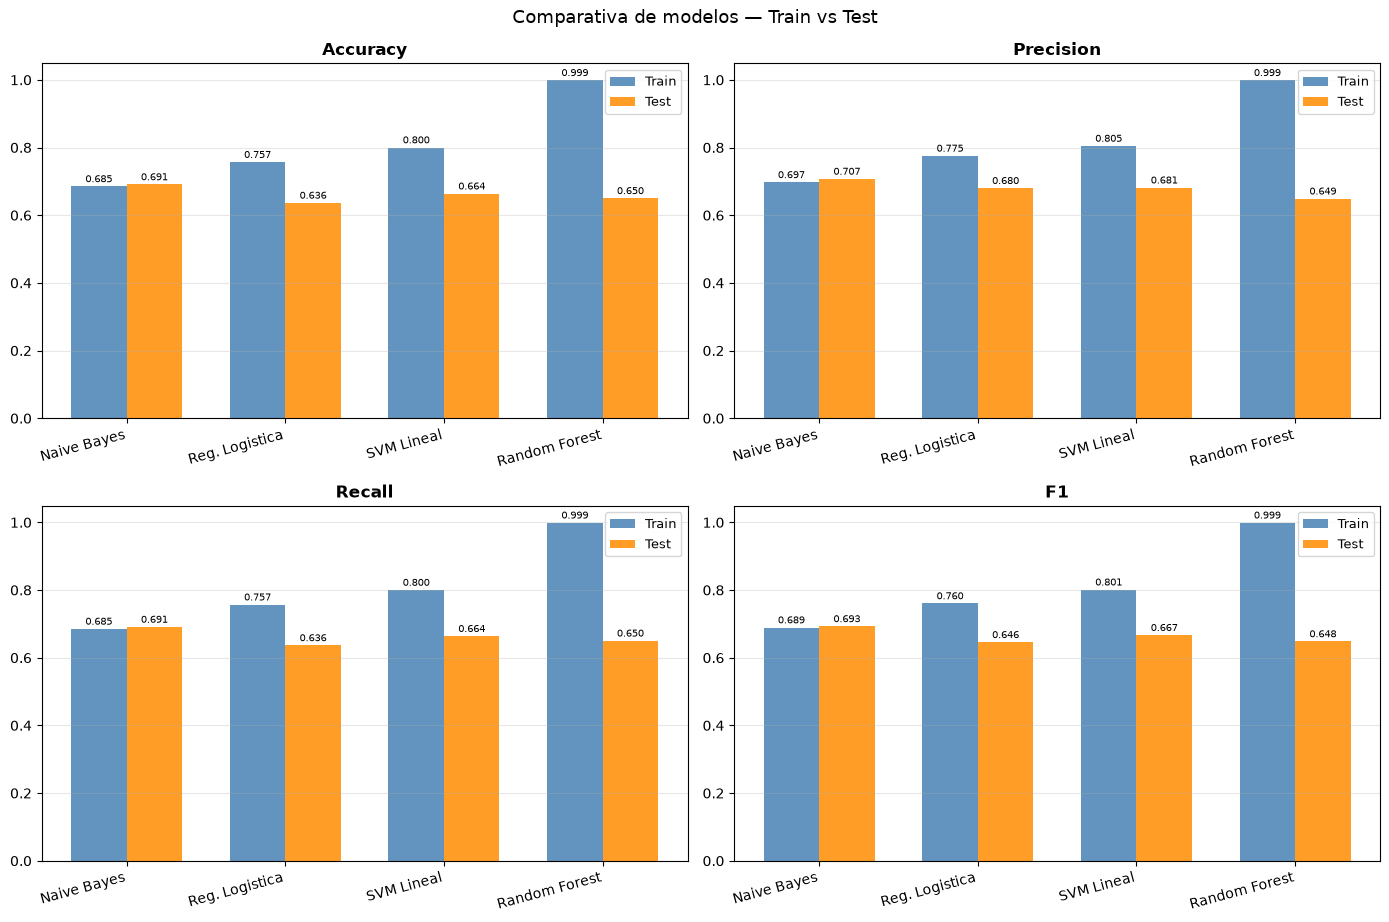

In [8]:
import numpy as np

pares = [
    ('Accuracy',  'Acc. train',        'Acc. test'),
    ('Precision', 'Precision (train)', 'Precision (test)'),
    ('Recall',    'Recall (train)',    'Recall (test)'),
    ('F1',        'F1 (train)',        'F1 (test)'),
]

nombres = df_resultados.index.tolist()
x       = np.arange(len(nombres))
width   = 0.35

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, (titulo, col_train, col_test) in enumerate(pares):
    ax = axes[i]
    vals_train = df_resultados[col_train].values
    vals_test  = df_resultados[col_test].values

    bars_train = ax.bar(x - width / 2, vals_train, width, label='Train', color='steelblue',  alpha=0.85)
    bars_test  = ax.bar(x + width / 2, vals_test,  width, label='Test',  color='darkorange', alpha=0.85)

    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(nombres, rotation=15, ha='right')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    for bar in list(bars_train) + list(bars_test):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.suptitle('Comparativa de modelos — Train vs Test', y=1.02, fontsize=13)
plt.show()

**NOTA**: Las matrices de confusión que se muestrán a continuación se muestran con frecuencias. Si las queréis ver en porcentajes, descomentar las siguietes líneas de `ConfusionMatrixDisplay`: 

```python
normalize='true',      # porcentaje por fila (recall por clase)
values_format='.1%',   # formato: 0.7 → 69.2%
```

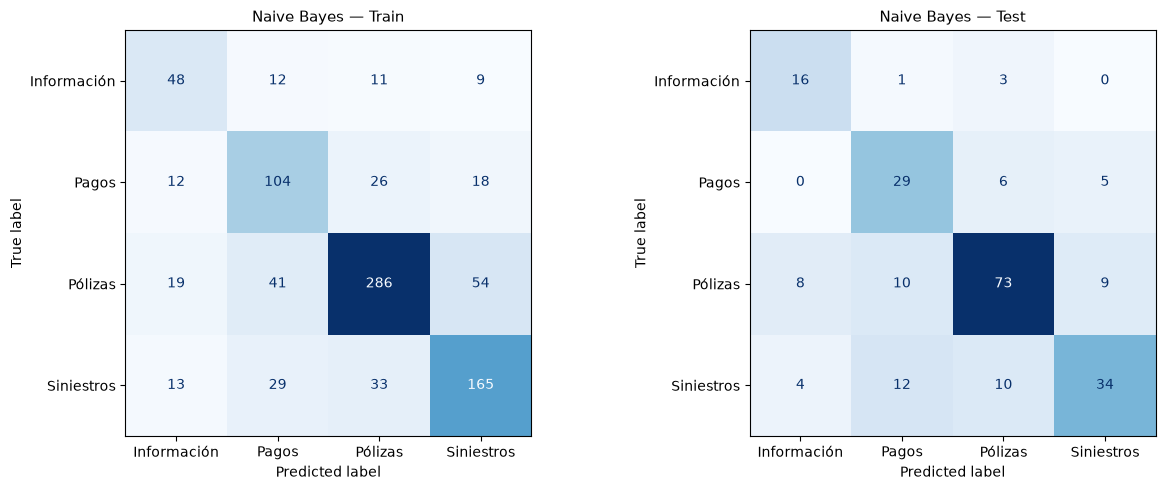

In [9]:
mejor_nombre  = df_resultados['F1 (test)'].idxmax()
mejor_modelo  = modelos[mejor_nombre]
y_pred_train  = mejor_modelo.predict(X_train)
y_pred_test   = mejor_modelo.predict(X_test)

clases = sorted(set(y))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train, y_pred_train,
    display_labels=clases,
    # normalize='true',      # porcentaje por fila (recall por clase)
    # values_format='.1%',   # formato: 0.7 → 69.2%
    colorbar=False,
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title(f'{mejor_nombre} — Train', fontsize=11)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=clases,
    # normalize='true',      # porcentaje por fila (recall por clase)
    # values_format='.1%',   # formato: 0.7 → 69.2%
    colorbar=False,
    cmap='Blues',
    ax=axes[1]
)
axes[1].set_title(f'{mejor_nombre} — Test', fontsize=11)

plt.tight_layout()
plt.show()

---

## 7. Mejor modelo y conclusiones

In [10]:
mejor_nombre = df_resultados['F1 (test)'].idxmax()
mejor_f1     = df_resultados.loc[mejor_nombre, 'F1 (test)']
mejor_modelo = modelos[mejor_nombre]

print(f'Mejor modelo: {mejor_nombre}')
print(f'F1 (test):    {mejor_f1:.4f}')
print()
print(df_resultados.loc[[mejor_nombre]])

Mejor modelo: Naive Bayes
F1 (test):    0.6926

             Acc. train  Acc. test  Precision (train)  Precision (test)  \
Modelo                                                                    
Naive Bayes      0.6852     0.6909             0.6972            0.7072   

             Recall (train)  Recall (test)  F1 (train)  F1 (test)  
Modelo                                                             
Naive Bayes          0.6852         0.6909      0.6891     0.6926  


### Razonamiento sobre la elección del modelo

El mejor modelo según el F1 ponderado en test es **Naive Bayes**, con un F1 de **0.6926**. El resultado merece un análisis en dos dimensiones: qué indica el nivel de ajuste y por qué Naive Bayes obtiene el mejor resultado.

#### Ajuste del modelo (train vs test)

Las métricas de entrenamiento (F1 = 0.6891) y test (F1 = 0.6926) son prácticamente idénticas. Esto indica que **no hay sobreajuste**: el modelo generaliza correctamente a datos nuevos. Un valor de F1 en torno a 0.69 refleja que la tarea tiene dificultad intrínseca — el dataset contiene ruido que ningún modelo puede eliminar por completo con la representación actual.

#### Por qué Naive Bayes es el mejor en este contexto

Con datasets ruidosos y vocabularios relativamente pequeños, la **simplicidad del modelo es una ventaja**, no una limitación:

1. **Robustez al ruido**: Naive Bayes estima la probabilidad de cada término de forma independiente. Los modelos más complejos (Regresión Logística, SVM) aprenden combinaciones de términos que pueden reflejar el ruido del corpus de entrenamiento en lugar de patrones reales, lo que perjudica su rendimiento en test.
2. **Pocos datos por clase**: con clases minoritarias como Información (100 muestras), los modelos lineales tienen menos ejemplos para aprender una frontera de decisión fiable. Naive Bayes se beneficia de la regularización implícita de su enfoque probabilístico.
3. **Alta dimensionalidad con señal débil**: cuando muchos términos del vocabulario son poco informativos (ruido), los modelos que asignan pesos individuales a cada término (Regresión Logística, SVM) pueden amplificar ese ruido; Naive Bayes lo amortigua al operar con probabilidades a priori.

#### Posibles mejoras

Un F1 de 0.69 deja margen de mejora. Las vías más habituales son sustituir BoW por TF-IDF (que reduce el peso de los términos comunes), ajustar hiperparámetros mediante validación cruzada, o incrementar el corpus con más ejemplos de las clases minoritarias.

---

## 8. Exportación de modelos

Guardamos el vectorizador BoW y el mejor modelo con `joblib`. El notebook de inferencia los cargará para clasificar nuevos textos sin necesidad de reentrenar.

In [11]:
os.makedirs('models', exist_ok=True)

joblib.dump(vectorizer,   'models/vectorizer_bow_polizas_seguros.pkl')
joblib.dump(mejor_modelo, 'models/mejor_modelo_polizas_seguros.pkl')

print(f'Vectorizador guardado en: models/vectorizer_bow_polizas_seguros.pkl')
print(f'Modelo guardado en:       models/mejor_modelo_polizas_seguros.pkl  ({mejor_nombre})')

Vectorizador guardado en: models/vectorizer_bow_polizas_seguros.pkl
Modelo guardado en:       models/mejor_modelo_polizas_seguros.pkl  (Naive Bayes)
